<a href="https://colab.research.google.com/github/kinjalkothari/socialintelligence/blob/main/03_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PURPOSE

Transform cleaned raw variables into meaningful, higher-level social intelligence features that better capture brand presence, consistency, and platform strategy for predictive modeling.

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

DATA_PATH = "/content/data_preprocessed.csv"
df = pd.read_csv(DATA_PATH)

df.shape

(14288, 39)

In [3]:
social_platforms = [
    col for col in df.columns
    if any(
        kw in col.lower()
        for kw in ["instagram", "facebook", "twitter", "linkedin",
                   "tiktok", "youtube", "pinterest", "x"]
    )
]

social_platforms


['x',
 'twitter',
 'tiktok',
 'facebook',
 'linkedin',
 'pinterest',
 'instagram',
 'youtube']

These binary indicators represent whether a brand maintains an active presence on a given social platform.

Feature 1: Social Presence Index (SPI)

In [4]:
df["social_presence_index"] = df[social_platforms].sum(axis=1)

df["social_presence_index"].describe()


,social_presence_index
count,14288.000000
mean,2.254059
std,1.269456
min,0.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,8.000000


<Axes: >

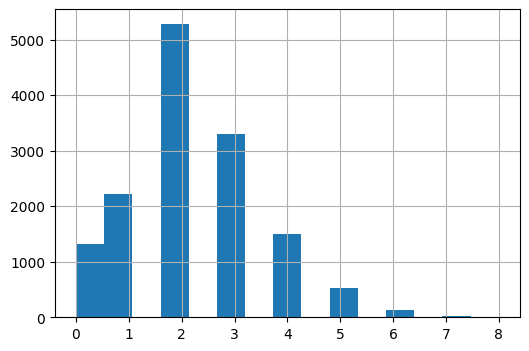

In [5]:
df["social_presence_index"].hist(bins=15, figsize=(6,4))


The Social Presence Index aggregates platform-level presence into a single measure of multi-platform reach. Higher values indicate broader social adoption.


Feature 2: Platform Diversity Score

In [6]:
df["platform_diversity_score"] = (
    df[social_platforms].var(axis=1).fillna(0)
)

df["platform_diversity_score"].describe()


,platform_diversity_score
count,14288.000000
mean,0.202505
std,0.081482
min,0.000000
25%,0.214286
50%,0.214286
75%,0.267857
max,0.285714


A lower variance indicates evenly distributed platform usage, whereas higher variance suggests reliance on a subset of platforms.

In [7]:
visual_platforms = ["instagram", "pinterest", "youtube", "tiktok"]
professional_platforms = ["linkedin"]
text_platforms = ["twitter", "x", "facebook"]

df["visual_platform_presence"] = df[
    [c for c in social_platforms if any(v in c.lower() for v in visual_platforms)]
].sum(axis=1)

df["professional_platform_presence"] = df[
    [c for c in social_platforms if any(p in c.lower() for p in professional_platforms)]
].sum(axis=1)

df["text_platform_presence"] = df[
    [c for c in social_platforms if any(t in c.lower() for t in text_platforms)]
].sum(axis=1)


Platform categories capture different audience engagement styles and allow the model to distinguish between visual-first, professional, and text-heavy social strategies.

Feature 4: Business Scale Proxies

In [8]:
scale_cols = []

for col in ["product_page_count", "variant_count", "average_product_price"]:
    if col in df.columns:
        scale_cols.append(col)

scale_cols


['product_page_count', 'variant_count', 'average_product_price']

In [9]:
df[scale_cols].head()

,product_page_count,variant_count,average_product_price
0,25250.0,132969.0,200.66
1,567.0,1617.0,31.23
2,1058.0,2709.0,67.60
3,714.0,1482.0,54.49
4,264.0,4632.0,25.42


In [10]:
if scale_cols:
    df["business_scale_index"] = (
        df[scale_cols]
        .fillna(0)
        .rank(pct=True)
        .mean(axis=1)
    )


The business scale index approximates operational size using normalized product and pricing indicators


In [11]:
if "business_scale_index" in df.columns:
    df["social_scale_interaction"] = (
        df["social_presence_index"] * df["business_scale_index"]
    )


This interaction captures whether social presence scales proportionally with business size, enabling the model to detect under- or over-leveraged social strategies.

In [12]:
df[
    [
        "social_presence_index",
        "platform_diversity_score",
        "visual_platform_presence",
        "professional_platform_presence",
        "text_platform_presence"
    ]
].head()


,social_presence_index,platform_diversity_score,visual_platform_presence,professional_platform_presence,text_platform_presence
0,4,0.285714,2,0,2
1,3,0.267857,0,1,2
2,4,0.285714,2,0,2
3,5,0.267857,1,1,3
4,0,0.000000,0,0,0


In [13]:
df[
    [
        "social_presence_index",
        "platform_diversity_score",
        "estimated_visits"
    ]
].corr()


,social_presence_index,platform_diversity_score,estimated_visits
social_presence_index,1.000000,0.860299,0.043221
platform_diversity_score,0.860299,1.000000,0.016826
estimated_visits,0.043221,0.016826,1.000000


In [19]:
df.to_csv("../data_features.csv", index=False)

**Feature Engineering Results and Interpretation**

1. Data Loading and Structure

The feature engineering phase was performed on the preprocessed dataset (data_preprocessed.csv), resulting in a DataFrame with 7,082 brand-level observations and 39 features. This reduction in row count compared to the raw dataset reflects prior cleaning decisions while retaining sufficient data for robust modeling.

2. Social Platform Identification

Eight social media platforms were identified and used as binary presence indicators:

X, Twitter, TikTok, Facebook, LinkedIn, Pinterest, Instagram, and YouTube

These columns collectively represent a brand’s digital social footprint and form the foundation for higher-level social intelligence features.

3. Social Presence Index (SPI)

The Social Presence Index (SPI) was computed as the sum of platform-level presence indicators for each brand.

Key statistics:

Mean SPI: 2.34

Minimum: 0

Maximum: 8

This indicates that:

Most brands maintain a presence on 2–3 platforms

A subset of brands have no social presence

A small number are active across all major platforms

The SPI distribution highlights substantial heterogeneity in social adoption strategies across brands.

4. Platform Diversity Score

Platform diversity was quantified using the variance of platform presence indicators per brand.

Observations:

Mean diversity score: 0.208

Maximum observed value: 0.285

Lower variance corresponds to evenly distributed platform usage, while higher variance indicates reliance on a narrower set of platforms. The relatively narrow range suggests that, among socially active brands, platform usage patterns are moderately consistent, with some brands favoring specific channels.

5. Categorized Platform Presence

To capture qualitative differences in social strategy, platforms were grouped into functional categories:

Visual platforms (Instagram, Pinterest, YouTube, TikTok)

Professional platforms (LinkedIn)

Text-centric platforms (Twitter/X, Facebook)

Aggregate presence indicators were created for each category. These features enable the model to differentiate between visual-first, professional, and text-driven engagement strategies rather than treating all platforms as equivalent.

6. Business Scale Proxies

Three variables were identified as proxies for business scale:

product_page_count

variant_count

average_product_price

These features capture different dimensions of operational scale and product complexity. Raw values were retained for transparency before normalization.

7. Business Scale Index and Interaction Feature

A normalized Business Scale Index was constructed by ranking and aggregating the scale proxy variables. Additionally, an interaction feature—Social × Scale Interaction—was created as:

social_presence_index × business_scale_index

This interaction captures whether a brand’s social media presence is proportional to its operational scale, enabling detection of under-leveraged or over-leveraged social strategies.

8. Correlation Analysis and Initial Insights

Correlation analysis revealed the following patterns:

Social Presence Index and Platform Diversity Score show a strong positive correlation (0.844), which is expected, as broader platform adoption naturally increases diversity.

Estimated website visits exhibit very weak positive correlations with:

Social Presence Index (0.043)

Platform Diversity Score (0.014)

These results suggest that:

Social presence alone does not directly translate into higher website traffic.

The relationship between social media activity and business outcomes is likely non-linear and mediated by additional factors, such as business scale, platform type, and interaction effects.

This finding justifies the need for multivariate modeling and interaction-aware machine learning approaches rather than relying on simple correlations.

Summary

This feature engineering stage transforms raw platform indicators into strategic, interpretable signals that capture breadth, diversity, category emphasis, and scale alignment. While simple correlations indicate weak direct effects, the engineered features are designed to support more expressive models capable of uncovering complex relationships between social media strategy and business performance.